<span style="color: orange;">Matplotlib和基于Matplotlib的三个库（Seaborn, Plotly, Pandas plotting）</span>  

这四个库是Python 数据可视化生态系统的核心。掌握它们能极大地提升你的数据分析和展示能力。


本教程结构如下：

<span style="color: magenta"> Matplotlib：万物的基础  </span>   

Seaborn 和 Plotly 对 Matplotlib 的主要改进

<span style="color: lightblue"> 教程一：Seaborn 详细教程 </span>   (用于统计与美学)  
<span style="color: lightblue">教程二：Plotly 详细教程 </span>   (用于交互与网络)  
<span style="color: lightblue"> 教程三：Pandas 自带作图教程 </span>   (用于快速探索)  


#### 总结：何时使用哪个库？


1. Matplotlib：万物的基础  
   
在学习其他库之前，必须了解 Matplotlib 是 Python 可视化的“祖父级”库。几乎所有其他库，包括 Seaborn 和 Pandas Plotting，底层都是构建在 Matplotlib 之上的。

* 优点：功能极其强大，控制力极强。你可以自定义图表的任何一个微小细节。
* 缺点：API 相对底层和繁琐，有时需要写很多代码才能实现一个简单的图表，且默认样式不够美观。


2. Seaborn 和 Plotly 对 Matplotlib 的主要改进  
   
这两个库的出现，就是为了解决 Matplotlib 的缺点。


<span style="color: cyan"> Seaborn 的改进： </span>   

2.1. 更简洁的 API：用更少的代码创建更复杂的统计图表。例如，在 Matplotlib 中画一个带回归线的散点图可能需要多行代码，而在 Seaborn 中通常只需一行。  

2.2. 更美观的默认样式：Seaborn 的默认主题、调色板和样式远比 Matplotlib 的现代和美观，几乎无需调整即可生成“出版级”的图表。 

2.3. 专注于统计可视化：Seaborn 内置了许多专门用于展示统计关系的功能，如分布图、分类数据图、线性模型可视化等，这是 Matplotlib 所不具备的。  

2.4. 与 Pandas 的深度集成：Seaborn 的函数设计能够非常自然地接受 Pandas DataFrame 作为输入，并能轻松地使用列名来分配颜色、大小、样式等。 

一句话总结 Seaborn：让 Matplotlib 变得更简单、更美观，并专注于统计分析。  


<span style="color: cyan">Plotly 的改进：</span>    

3.1. 原生交互性 (Interactive)：这是 Plotly 最大的优势。用 Plotly 生成的图表是交互式的。你可以用鼠标悬停查看数据、缩放、平移、点击图例来隐藏/显示数据，而这一切都无需额外代码。Matplotlib 和 Seaborn 生成的默认是静态图片。

4.2. Web 原生：Plotly 的图表是基于 JSON 和 JavaScript (Plotly.js) 构建的。这意味着你可以轻松地将图表嵌入到网页、在线报告和 Dash 应用中，它们看起来和行为都像现代的网络应用元素。

4.3. 更现代的图表类型：Plotly 提供了许多 Matplotlib/Seaborn 不容易实现的现代图表，如旭日图 (Sunburst)、平行坐标图、三维网络图、地理地图（Choropleth maps）等。

4.4. 声明式 API (Plotly Express)：Plotly Express 提供了一个极其简洁的声明式 API，你只需“声明”你想要的数据和映射方式，它就会为你生成一个完整的、交互式的图表。

一句话总结 Plotly：它不是对 Matplotlib 的“改进”，而是一个全新的、为交互式和网络时代打造的可视化引擎。



#### 教程一：Seaborn 详细教程
目标：用最少的代码创建美观的统计图表。

第一步：安装和导入


!pip install seaborn matplotlib pandas

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 

第二步：核心概念 - Figure-level vs. Axes-level
* Axes-level 函数：在一个已经存在的 matplotlib.pyplot.Axes 对象上绘图（例如 scatterplot, histplot, boxplot）。你可以精确控制每个子图画什么。
* Figure-level 函数：会自己创建一个 Matplotlib Figure 和 Axes，并能轻松创建分面网格（多个子图）。例如 relplot, displot, catplot。

第三步：加载数据

Seaborn 自带一些示例数据集，非常适合学习。

In [2]:
# 加载 "tips" (小费) 数据集
tips = sns.load_dataset("tips")
print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [3]:
tips.shape

(244, 7)

第四步：常用图表实战
1. 分布图 (Distribution Plots) - 查看单个变量的分布
直方图 (histplot)

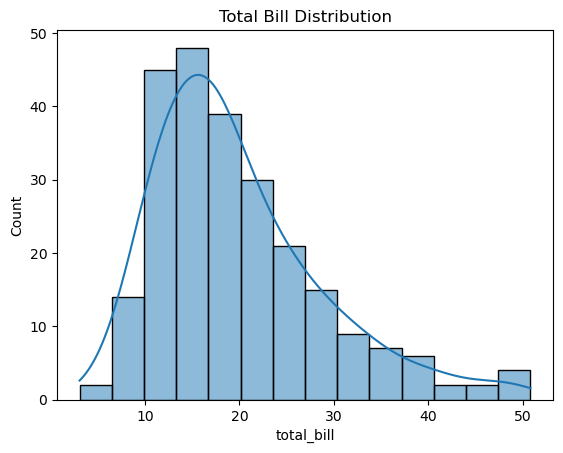

In [4]:
sns.histplot(data=tips, x="total_bill", kde=True) # kde=True 会加上KDE曲线
plt.title("Total Bill Distribution")
plt.show()

核密度估计图 (kdeplot) - 平滑版的直方图

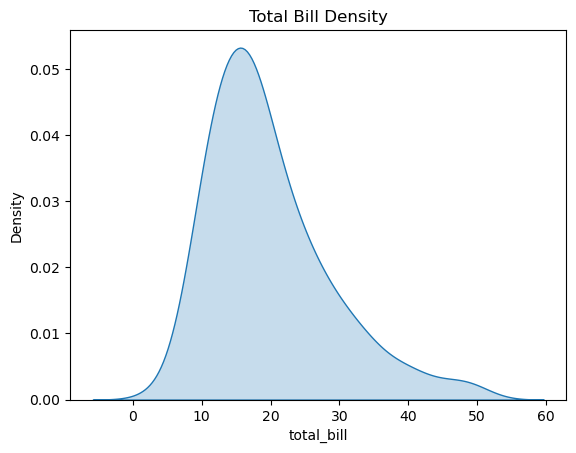

In [5]:
sns.kdeplot(data=tips, x="total_bill", fill=True) # fill=True 填充曲线下方
plt.title("Total Bill Density")
plt.show()

2. 关系图 (Relational Plots) - 查看两个变量间的关系
散点图 (scatterplot)
使用 hue 参数引入第三个分类变量，用颜色区分。

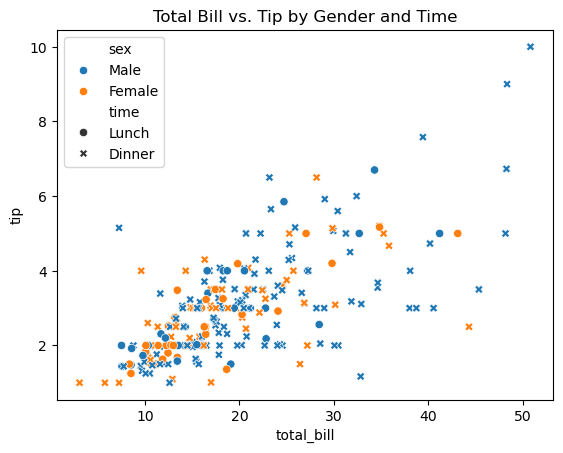

In [5]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex", style="time")
plt.title("Total Bill vs. Tip by Gender and Time")
plt.show()

3. 分类图 (Categorical Plots) - 查看数值变量在不同类别下的分布

箱形图 (boxplot) - 查看中位数、四分位数和异常值

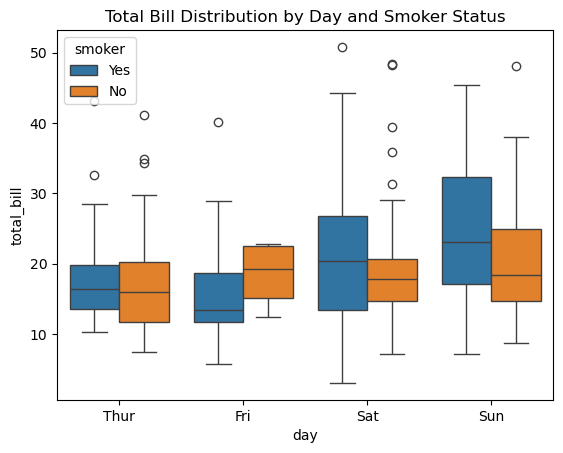

In [ ]:
sns.boxplot(data=tips, x="day", y="total_bill", hue="smoker") # hue 原意是：“the attribute of color" 即“颜色属性”
plt.title("Total Bill Distribution by Day and Smoker Status")
plt.show()

小提琴图 (violinplot) - 箱形图和核密度估计的结合

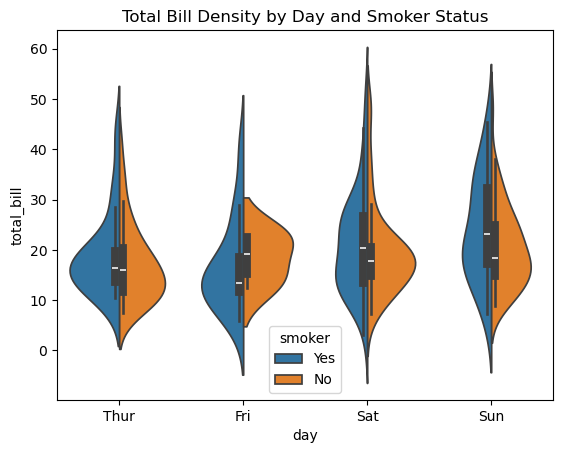

In [6]:
sns.violinplot(data=tips, x="day", y="total_bill", hue="smoker", split=True) # split=True 将hue的两个类别画在同一个小提琴的两侧
plt.title("Total Bill Density by Day and Smoker Status")
plt.show()

4. 矩阵图 (Matrix Plots) - 查看多个变量间的关系


热力图 (heatmap) - 展示矩阵数据的相关性

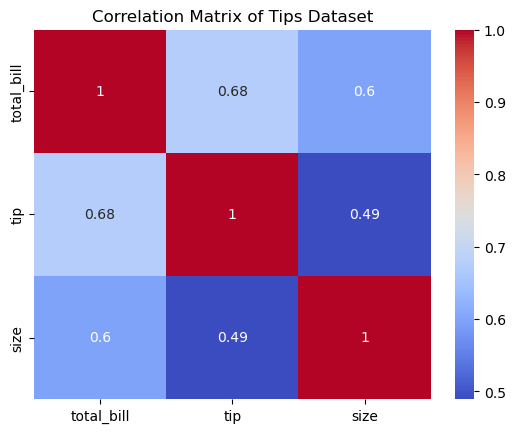

In [ ]:
# 首先计算数值列的相关性矩阵 
numeric_cols = tips.select_dtypes(include=['float64', 'int64']) # 只保留数值列（float64 / int64），返回 DataFrame
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm") # annot=True 在格子上显示数值 # 蓝-白-红渐变
plt.title("Correlation Matrix of Tips Dataset")
plt.show()

4. 教程二：Plotly 详细教程
目标：创建交互式的、适合网页展示的图表。
第一步：安装和导入

我们主要使用 plotly.express，它是 Plotly 的高级封装，非常易用。

In [8]:
import plotly.express as px
import pandas as pd

第二步：加载数据
Plotly 也自带一些非常好的示例数据集。

In [9]:
# 加载 Gapminder 数据集，包含各国多年的经济指标
gapminder = px.data.gapminder()
print(gapminder.head())

       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


第三步：常用图表实战 (体验交互性)
1. 散点图 (px.scatter)
交互性：将鼠标悬停在点上可以看到详细数据。
参数：size 和 color 可以轻松映射到数据列。
动画：animation_frame 参数可以创建动画！

In [10]:
# 2007年的数据
gapminder_2007 = gapminder.query("year==2007")

fig = px.scatter(
    gapminder_2007,
    x="gdpPercap",
    y="lifeExp",
    color="continent",          # 按大洲着色
    size="pop",                 # 按人口大小调整点的大小
    hover_name="country",       # 鼠标悬停时显示国家名称
    log_x=True,                 # X轴使用对数刻度
    size_max=60,                # 最大点的大小
    title="Life Expectancy vs. GDP per Capita (2007)"
)
fig.show() # 在Jupyter Notebook或浏览器中显示交互式图表

In [36]:
#import seaborn as sns
import numpy as np

import plotly.express as px
import numpy as np

gapminder_2007 = gapminder.query("year==2007").copy()
gapminder_2007['logPop'] = (np.log(gapminder_2007['pop'] + 1) /np.log(1.2)  - 60 ) * 5 # ① 数值 ÷10
# print(min(gapminder_2007['logPop'])) # 66 
fig = px.scatter(
    gapminder_2007,
    x="gdpPercap",
    y="lifeExp",
    color="continent",
    size="logPop",        # ← 列名（对数人口 ÷10）
    size_max=20,                # ← 最大像素 ÷10（基准缩放） , 600px 
    hover_name="country",
    log_x=True,
    title="Life Expectancy vs. GDP per Capita (2007) — log(pop)/10"
)
fig.show()

In [42]:
import numpy as np 

gapminder_2007 = gapminder.query("year==2007").copy()
gapminder_2007['sqrtPop_small'] = np.sqrt(gapminder_2007['pop'] + 1) / 10   # ① 开根号 ÷10

fig = px.scatter(
    gapminder_2007,
    x="gdpPercap",
    y="lifeExp",
    color="continent",
    size="sqrtPop_small",       # ← 开根号 ÷10
    size_max=15,
    hover_name="country",
    log_x=True,
    title="Life Expectancy vs. GDP per Capita (2007) — √pop/10"
)
fig.show()

2. 条形图 (px.bar)

In [43]:
# 计算每个大洲的平均GDP
continent_gdp = gapminder.groupby('continent')['gdpPercap'].mean().reset_index()

fig = px.bar(
    continent_gdp,
    x='continent',
    y='gdpPercap',
    color='continent',
    title="Average GDP per Capita by Continent"
)
fig.show()

3. 动画散点图 (Plotly 的“杀手级”功能)

In [45]:
fig = px.scatter(
    gapminder,
    x="gdpPercap",
    y="lifeExp",
    color="continent",
    size="pop",
    hover_name="country",
    log_x=True,
    size_max=30,# change here 
    animation_frame="year", # 按年份创建动画帧
    animation_group="country", # 确保每个国家在动画中是连续的
    range_y=[20, 90], # 锁定Y轴范围
    title="The Evolution of Health and Wealth of Nations"
)
fig.show()

4. 地理地图 (px.choropleth)

In [46]:
fig = px.choropleth(
    gapminder,
    locations="iso_alpha", # 国家三字母代码
    color="lifeExp",       # 按人均寿命着色
    hover_name="country",
    animation_frame="year",
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Global Life Expectancy Over Time"
)
fig.show()

5. 教程三：Pandas 自带作图教程
目标：直接在 DataFrame 上进行快速、便捷的可视化探索。

第一步：核心概念
Pandas 的作图功能是 Matplotlib 的一个便捷封装。你可以通过 DataFrame.plot() 或 Series.plot() 这个访问器 (accessor) 来调用所有功能。
第二步：导入库和创建数据

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # 仍然需要它来显示和调整图表

# 创建一个示例 DataFrame
data = {
    'A': np.random.randn(10).cumsum(),
    'B': np.random.randn(10).cumsum(),
    'C': np.random.randn(10).cumsum(),
    'D': np.random.randint(0, 10, 10)
}
df = pd.DataFrame(data)
print(df)

          A         B         C  D
0 -0.490425  1.397103 -0.195544  8
1 -0.310536  0.385716 -0.459365  9
2 -0.703028  0.660350 -0.931461  7
3 -1.297137 -0.338128 -2.132353  1
4 -0.513207 -0.603811 -1.808675  7
5  1.434270 -0.436099 -0.838663  6
6  1.540342  0.859644 -1.263565  8
7  0.577517  1.751930 -2.041523  0
8 -0.725547  2.506365 -2.071990  0
9  0.153241  2.847897 -1.603948  1


第三步：常用图表实战
1. 默认折线图 
2. .plot() 或 .plot.line()   
默认情况下，<span style="color: red;"> .plot() 会为 DataFrame 中的每一个数值列画一条折线。.</span> 

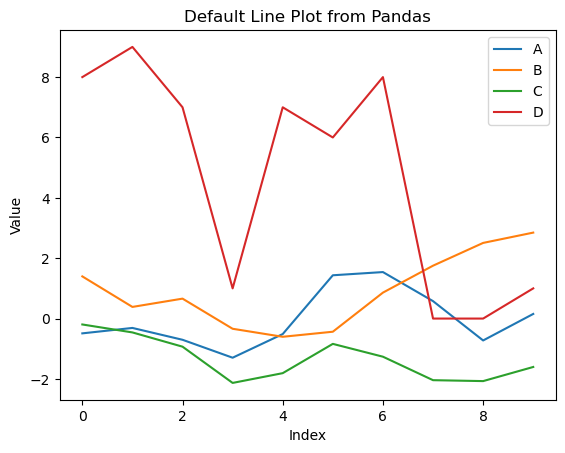

In [48]:
df.plot()
plt.title("Default Line Plot from Pandas")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

2. 指定图表类型 (kind 参数)
kind 参数是 Pandas 绘图的“总开关”。

条形图 (kind='bar')

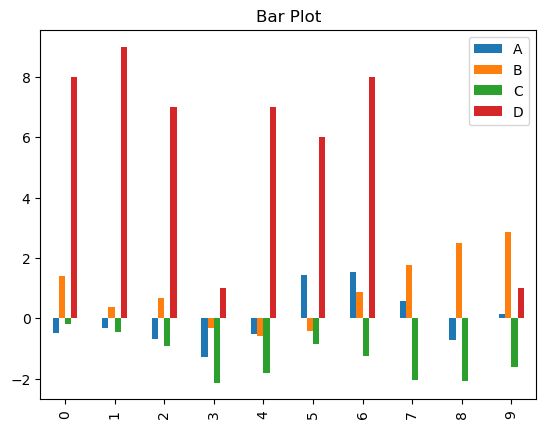

In [49]:
df.plot(kind='bar')
plt.title("Bar Plot")
plt.show()
# ```*   **堆叠条形图 (`stacked=True`)**


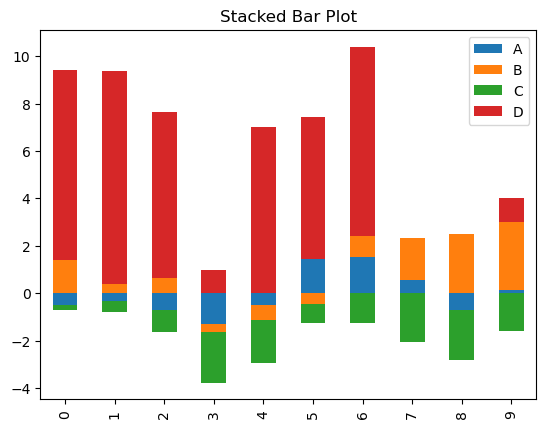

In [51]:
# ```python
df.plot(kind='bar', stacked=True)
plt.title("Stacked Bar Plot")
plt.show()

直方图 (kind='hist') - 查看单列的分布

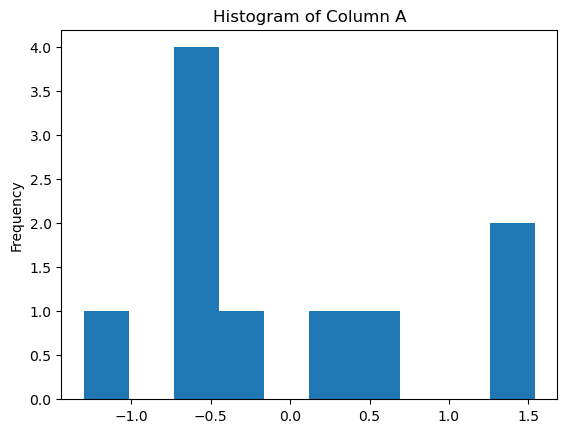

In [52]:
df['A'].plot(kind='hist', bins=10) # bins指定箱子数量
plt.title("Histogram of Column A")
plt.show()

散点图 (kind='scatter') - 必须指定 x 和 y

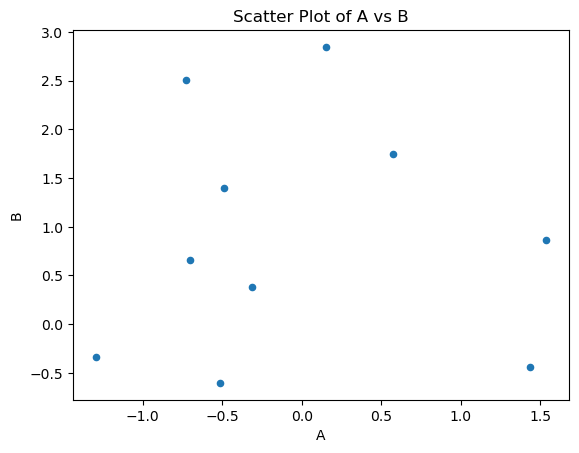

In [53]:
df.plot(kind='scatter', x='A', y='B')
plt.title("Scatter Plot of A vs B")
plt.show()

箱形图 (kind='box')

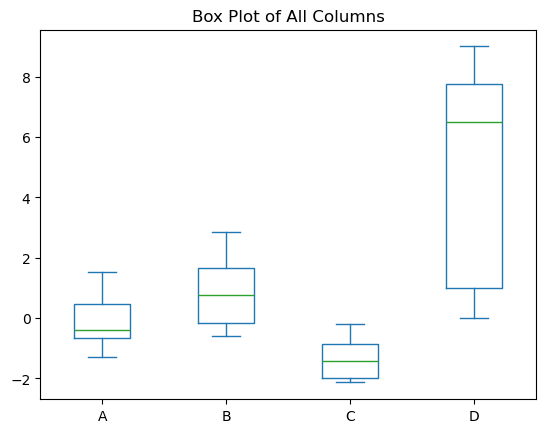

In [54]:
df.plot(kind='box')
plt.title("Box Plot of All Columns")
plt.show()

3. 使用便捷方法
除了 kind 参数，你还可以使用更直接的方法：
df.plot.bar(), df.plot.hist(), df.plot.scatter() 等。

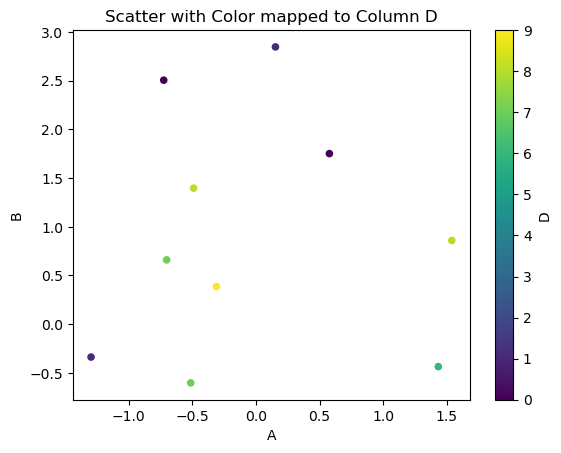

In [55]:
# 等同于 df.plot(kind='scatter', x='A', y='B') <<<<================
df.plot.scatter(x='A', y='B', c='D', colormap='viridis') # 还可以传入matplotlib的参数
plt.title("Scatter with Color mapped to Column D")
plt.show()





### 6. 总结：何时使用哪个库？

| 场景 | 推荐库 | 理由 |
| :--- | :--- | :--- |
| **快速探索性数据分析 (EDA)** | **Pandas `.plot()`** | 最快、最方便，直接在数据上操作，无需切换思维。 |
| **创建美观的统计图表** | **Seaborn** | API简洁，默认样式好看，专注于统计关系的可视化。 |
| **需要交互式图表、动画或网页嵌入** | **Plotly** | 这是它的核心优势，无出其右。非常适合制作报告和仪表盘。 |
| **需要对图表进行精细的、像素级的控制** | **Matplotlib** | 当其他库无法满足你特定的自定义需求时，回到 Matplotlib。 |

**最佳实践**：在一次分析中，你完全可以**混合使用**这些库。例如，用 Pandas `.plot()` 快速查看数据，用 Seaborn 深入探索